# 06. Statistical Exploratory Data Analysis
## 📚 Learning Objectives

By completing this notebook, you will:
- Perform comprehensive statistical EDA
- Identify data distributions and patterns
- Detect correlations and relationships
- Generate statistical summaries and insights

## 🔗 Prerequisites

- ✅ Examples 01–05 (data loading, cleaning, transformation, EDA)
- ✅ Understanding of pandas DataFrames

**Leads to:** Example 07 (cuDF), Example 08 (Feature extraction).

---

---

## The Story

**BEFORE**: You have clean data but don't know how to explore and understand it systematically.

**AFTER**: You'll learn EDA techniques: statistical summaries, visualizations, and discovering insights from data!

**Why this matters**: Statistical Exploratory Data Analysis is essential for building complete, professional data science solutions!

---

**All concepts are explained in the code comments below - you can learn everything from this notebook alone!**

---

## 🔗 Building on Data Cleaning

**After cleaning data, what's next?**
- We've cleaned missing values and duplicates
- But we don't understand the data yet!
- We need to explore and discover patterns

**This notebook teaches EDA!**
- We'll learn **statistical summaries** - understand data distributions
- We'll learn **correlation analysis** - find relationships
- We'll learn **pattern detection** - discover insights
- We'll learn **data profiling** - comprehensive understanding

**This is how you understand your data before modeling!**

---

## Learning Objectives
1. Generate statistical summaries (mean, median, std, quartiles)
2. Analyze correlations between variables
3. Identify data distributions and patterns
4. Create comprehensive data profiles

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Dataset
- pandas, scipy/stats, viz libraries

**Outputs:** What you'll see when you run the cells

- Statistical summaries
- Plots and tables

---

In [1]:
# WHAT: Import libraries and preview the four statistical-EDA topics.
# WHY: Statistical EDA quantifies what plots show - numbers and pictures should always confirm each other.

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported!")
print("\n📚 This notebook covers:")
print("   - Statistical summaries")
print("   - Correlation analysis")
print("   - Distribution analysis")
print("   - Data profiling")

✅ Libraries imported!

📚 This notebook covers:
   - Statistical summaries
   - Correlation analysis
   - Distribution analysis
   - Data profiling


In [2]:
# Step 2: Create sample dataset (with REAL relationships built in)
np.random.seed(42)
n = 1000
age = np.clip(np.random.normal(35, 10, n), 18, 70)
education_years = np.clip(np.random.normal(14, 3, n), 6, 22)
# Income depends on education and age (plus noise) - so correlations exist
income = 12000 + 2600 * education_years + 350 * age + np.random.normal(0, 8000, n)
# Satisfaction depends mildly on income
satisfaction = np.clip(3 + income / 40000 * 2 + np.random.normal(0, 1.5, n), 1, 10)

df = pd.DataFrame({
    'age': age,
    'income': income,
    'education_years': education_years,
    'satisfaction': satisfaction,
})

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset shape: (1000, 4)

First 5 rows:
         age        income  education_years  satisfaction
0  39.967142  67902.045741        18.198066      3.533391
1  33.617357  66222.068307        16.773901      5.020526
2  41.476885  57042.667401        14.178891      5.231725
3  50.230299  58470.805394        12.059190      8.755072
4  32.658466  50127.687699        16.094670      6.341214


In [3]:
# WHAT: Produce describe() output plus per-column mean/median/std/min/max.
# WHY: Comparing mean vs median is a quick skew check - a big gap means outliers or a long tail.

# Step 3: Statistical Summary
print("=" * 70)
print("1. Statistical Summary")
print("=" * 70)

print("\nDescriptive Statistics:")
print(df.describe())

print("\n\nKey Statistics:")
for col in df.columns:
    print(f"\n{col}:")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std: {df[col].std():.2f}")
    print(f"  Min: {df[col].min():.2f}")
    print(f"  Max: {df[col].max():.2f}")

1. Statistical Summary

Descriptive Statistics:
               age        income  education_years  satisfaction
count  1000.000000   1000.000000      1000.000000   1000.000000
mean     35.316459  61361.396152        14.213062      6.037330
std       9.507432  11426.761355         2.973610      1.621147
min      18.000000  28851.585923         6.000000      1.000000
25%      28.524097  53699.606978        12.181275      4.955699
50%      35.253006  60951.913732        14.189231      6.015516
75%      41.479439  68936.030454        16.186647      7.143939
max      70.000000  92200.554310        22.000000     10.000000


Key Statistics:

age:
  Mean: 35.32
  Median: 35.25
  Std: 9.51
  Min: 18.00
  Max: 70.00

income:
  Mean: 61361.40
  Median: 60951.91
  Std: 11426.76
  Min: 28851.59
  Max: 92200.55

education_years:
  Mean: 14.21
  Median: 14.19
  Std: 2.97
  Min: 6.00
  Max: 22.00

satisfaction:
  Mean: 6.04
  Median: 6.02
  Std: 1.62
  Min: 1.00
  Max: 10.00



2. Correlation Analysis

Correlation Matrix:
                      age    income  education_years  satisfaction
age              1.000000  0.281502        -0.040874      0.088359
income           0.281502  1.000000         0.656564      0.326591
education_years -0.040874  0.656564         1.000000      0.178433
satisfaction     0.088359  0.326591         0.178433      1.000000


Strong Correlations (|r| > 0.5):
  income ↔ education_years: 0.657


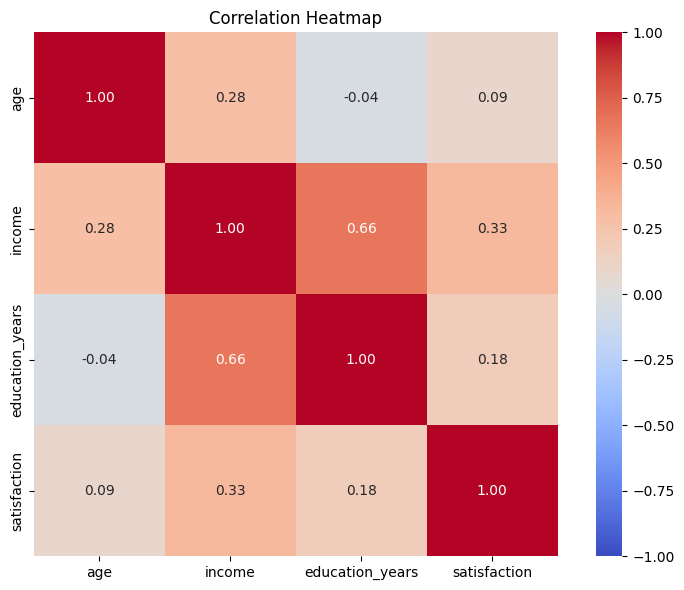

✓ Correlation heatmap plotted


In [4]:
# WHAT: Compute the correlation matrix, list strong pairs (|r| > 0.5), and draw a heatmap.
# WHY: Correlations point to candidate predictors and redundant features - but remember correlation is not causation.

# Step 4: Correlation Analysis
print("\n" + "=" * 70)
print("2. Correlation Analysis")
print("=" * 70)

correlation_matrix = df.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

print("\n\nStrong Correlations (|r| > 0.5):")
n_strong = 0
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > 0.5:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            print(f"  {col1} ↔ {col2}: {corr:.3f}")
            n_strong += 1
if n_strong == 0:
    print("  (none above the 0.5 threshold)")

# Visualize the whole matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
print("✓ Correlation heatmap plotted")


3. Distribution Analysis

Skewness (measure of asymmetry):
  age: 0.265
  income: 0.044
  education_years: -0.046
  satisfaction: -0.016


Kurtosis (measure of tail heaviness):
  age: -0.227
  income: -0.112
  education_years: -0.075
  satisfaction: -0.263


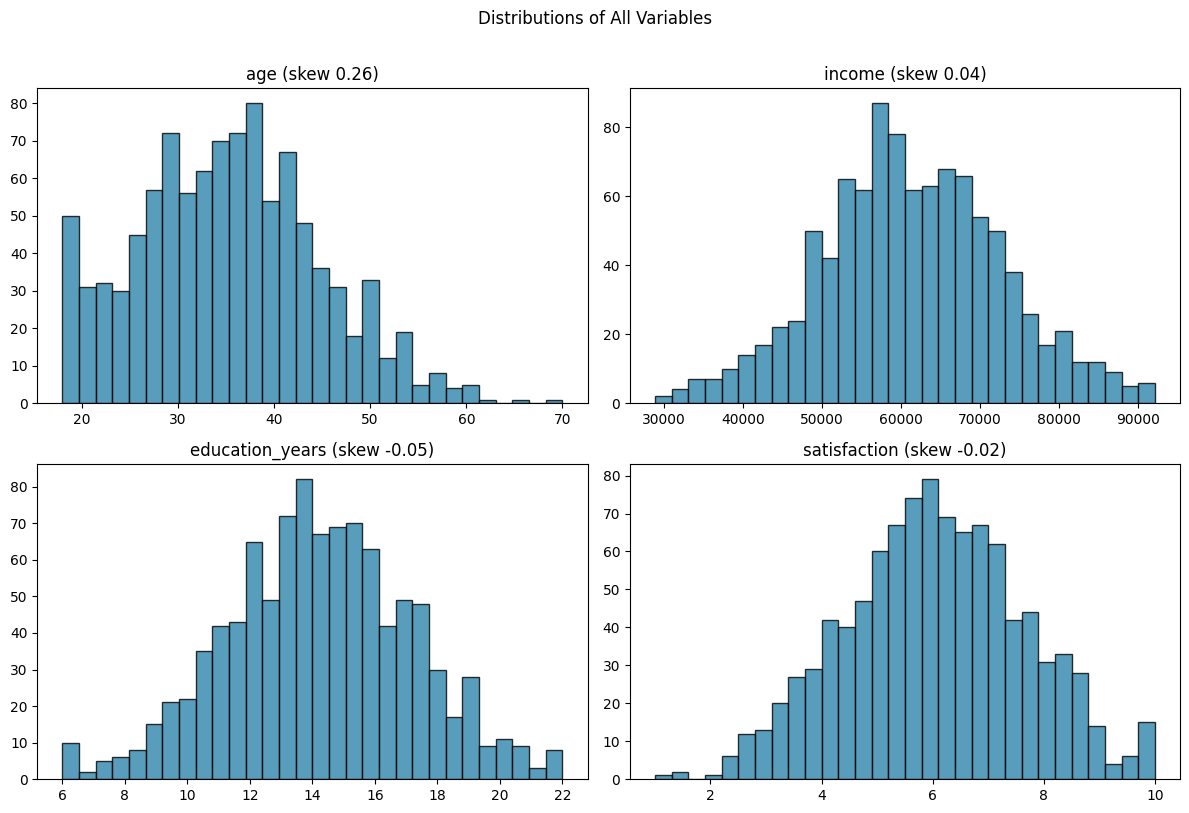

✓ Distribution histograms plotted

Summary

What this EDA found (computed above):
  - describe() summarized all 4 numeric variables
  - Strongest relationship: income ↔ education_years
    (r = 0.657) - visible in the heatmap
  - Skewness/kurtosis quantified each distribution's shape,
    confirmed visually by the histograms

✅ Statistical EDA - summaries, plots, and insights complete!


In [5]:
# WHAT: Measure skewness and kurtosis per column and plot every distribution.
# WHY: Shape statistics tell you which columns need transforming before modeling (see Example 3's log transform).

# Step 5: Distribution Analysis
print("\n" + "=" * 70)
print("3. Distribution Analysis")
print("=" * 70)

print("\nSkewness (measure of asymmetry):")
for col in df.select_dtypes(include=[np.number]).columns:
    skew = df[col].skew()
    print(f"  {col}: {skew:.3f}")
    if abs(skew) > 1:
        print(f"    → Highly skewed!")

print("\n\nKurtosis (measure of tail heaviness):")
for col in df.select_dtypes(include=[np.number]).columns:
    kurt = df[col].kurtosis()
    print(f"  {col}: {kurt:.3f}")

# Visualize every distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), df.columns):
    ax.hist(df[col], bins=30, color='#2E86AB', edgecolor='black', alpha=0.8)
    ax.set_title(f'{col} (skew {df[col].skew():.2f})')
plt.suptitle('Distributions of All Variables', y=1.01)
plt.tight_layout()
plt.show()
print("✓ Distribution histograms plotted")

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
strongest = correlation_matrix.where(~np.eye(len(correlation_matrix), dtype=bool)).abs().stack().idxmax()
print(f"""
What this EDA found (computed above):
  - describe() summarized all {df.shape[1]} numeric variables
  - Strongest relationship: {strongest[0]} ↔ {strongest[1]}
    (r = {correlation_matrix.loc[strongest[0], strongest[1]]:.3f}) - visible in the heatmap
  - Skewness/kurtosis quantified each distribution's shape,
    confirmed visually by the histograms
""")
print("✅ Statistical EDA - summaries, plots, and insights complete!")

## 📚 References

1. Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
2. Anscombe, F. J. (1973). *Graphs in Statistical Analysis*. The American Statistician, 27(1), 17-21. <https://doi.org/10.1080/00031305.1973.10478966>
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2nd ed. Springer. <https://www.statlearning.com>